
</p>

<br/>
  
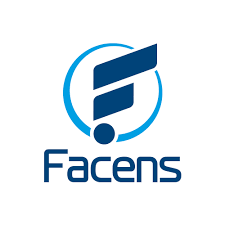




# Aprendizado de Máquinas
### 2023PGS2M2
----

## <center> Deploy dos Modelos </center>

Implementação e entendimento de deploy de modelos

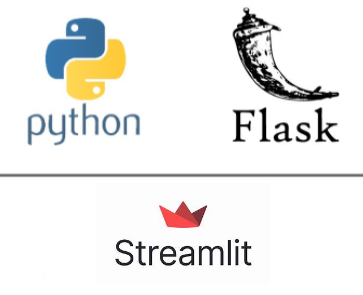

Banco de dados:
- Iris
- Cats and Dogs



## 1) Treinando o Modelo

In [1]:
# Importando nossas libs
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, accuracy_score, classification_report, precision_score, recall_score, \
                            f1_score, ConfusionMatrixDisplay
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn import datasets
import random
from glob import glob
from tqdm.notebook import tqdm

from sklearn.pipeline import Pipeline
from sklearn.decomposition import PCA
from sklearn.model_selection import GridSearchCV, KFold, StratifiedKFold, cross_val_score

# Nossos Algoritmos
from sklearn.naive_bayes import GaussianNB
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.cluster import KMeans
from sklearn.svm import SVC
from sklearn.ensemble import VotingClassifier, GradientBoostingClassifier, RandomForestClassifier

In [2]:
pd.__version__

'2.2.2'

In [3]:
# Vamos treinar no dataset Iris
d_iris = datasets.load_iris()

In [15]:
d_iris

{'data': array([[5.1, 3.5, 1.4, 0.2],
        [4.9, 3. , 1.4, 0.2],
        [4.7, 3.2, 1.3, 0.2],
        [4.6, 3.1, 1.5, 0.2],
        [5. , 3.6, 1.4, 0.2],
        [5.4, 3.9, 1.7, 0.4],
        [4.6, 3.4, 1.4, 0.3],
        [5. , 3.4, 1.5, 0.2],
        [4.4, 2.9, 1.4, 0.2],
        [4.9, 3.1, 1.5, 0.1],
        [5.4, 3.7, 1.5, 0.2],
        [4.8, 3.4, 1.6, 0.2],
        [4.8, 3. , 1.4, 0.1],
        [4.3, 3. , 1.1, 0.1],
        [5.8, 4. , 1.2, 0.2],
        [5.7, 4.4, 1.5, 0.4],
        [5.4, 3.9, 1.3, 0.4],
        [5.1, 3.5, 1.4, 0.3],
        [5.7, 3.8, 1.7, 0.3],
        [5.1, 3.8, 1.5, 0.3],
        [5.4, 3.4, 1.7, 0.2],
        [5.1, 3.7, 1.5, 0.4],
        [4.6, 3.6, 1. , 0.2],
        [5.1, 3.3, 1.7, 0.5],
        [4.8, 3.4, 1.9, 0.2],
        [5. , 3. , 1.6, 0.2],
        [5. , 3.4, 1.6, 0.4],
        [5.2, 3.5, 1.5, 0.2],
        [5.2, 3.4, 1.4, 0.2],
        [4.7, 3.2, 1.6, 0.2],
        [4.8, 3.1, 1.6, 0.2],
        [5.4, 3.4, 1.5, 0.4],
        [5.2, 4.1, 1.5, 0.1],
  

In [5]:
X = d_iris.data
y = d_iris.target

In [6]:
X_norm = StandardScaler().fit_transform(X)

In [7]:
# Test Split
X_train, X_test, y_train, y_test = train_test_split(X_norm, y, test_size=0.2, random_state=42)

In [19]:
param_grid = {'C': [0.1, 1, 10, 100],
              'gamma': [0.1, 1, 10, 100],
              'kernel': ['rbf', 'linear']
}

In [23]:
# Our SVM Model on GridSearch
grid_svm = GridSearchCV(SVC(), param_grid, verbose = 3, cv=10)

In [24]:
grid_svm.fit(X_norm, y)

Fitting 10 folds for each of 32 candidates, totalling 320 fits
[CV 1/10] END .....C=0.1, gamma=0.1, kernel=rbf;, score=0.800 total time=   0.0s
[CV 2/10] END .....C=0.1, gamma=0.1, kernel=rbf;, score=0.867 total time=   0.0s
[CV 3/10] END .....C=0.1, gamma=0.1, kernel=rbf;, score=0.933 total time=   0.0s
[CV 4/10] END .....C=0.1, gamma=0.1, kernel=rbf;, score=0.933 total time=   0.0s
[CV 5/10] END .....C=0.1, gamma=0.1, kernel=rbf;, score=0.867 total time=   0.0s
[CV 6/10] END .....C=0.1, gamma=0.1, kernel=rbf;, score=0.867 total time=   0.0s
[CV 7/10] END .....C=0.1, gamma=0.1, kernel=rbf;, score=0.867 total time=   0.0s
[CV 8/10] END .....C=0.1, gamma=0.1, kernel=rbf;, score=0.933 total time=   0.0s
[CV 9/10] END .....C=0.1, gamma=0.1, kernel=rbf;, score=0.933 total time=   0.0s
[CV 10/10] END ....C=0.1, gamma=0.1, kernel=rbf;, score=1.000 total time=   0.0s
[CV 1/10] END ..C=0.1, gamma=0.1, kernel=linear;, score=1.000 total time=   0.0s
[CV 2/10] END ..C=0.1, gamma=0.1, kernel=linea

GridSearchCV(cv=10, estimator=SVC(),
             param_grid={'C': [0.1, 1, 10, 100], 'gamma': [0.1, 1, 10, 100],
                         'kernel': ['rbf', 'linear']},
             verbose=3)

In [26]:
best_params = grid_svm.best_params_
print(best_params)

{'C': 1, 'gamma': 0.1, 'kernel': 'rbf'}

In [27]:
best_score = grid_svm.best_score_
print(best_score)

0.9800000000000001


In [28]:
best_estimator = grid_svm.best_estimator_
print(best_estimator)

SVC(C=1, gamma=0.1)


In [29]:
# Validando resultados no teste final
y_pred = grid_svm.predict(X_test)
cm = confusion_matrix(y_test, y_pred)
print(cm)
print(classification_report(y_test, y_pred))

[[10  0  0]
 [ 0  9  0]
 [ 0  0 11]]
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        10
           1       1.00      1.00      1.00         9
           2       1.00      1.00      1.00        11

    accuracy                           1.00        30
   macro avg       1.00      1.00      1.00        30
weighted avg       1.00      1.00      1.00        30



## 2) Model Persistence

In [30]:
# Salvando o modelo treinado para ser carregado posteriormente
# lib necessária
import joblib

In [31]:
# Salvando, aqui teremos um arquivo com os pesos do classificador
joblib.dump(grid_svm, 'svm_26.joblib')

['svm_26.joblib']

In [32]:
# Carregando de volta os pesos, ele cria diretamente o SVC
svm_loaded = joblib.load('svm_26.joblib')

In [35]:
svm_loaded

GridSearchCV(cv=10, estimator=SVC(),
             param_grid={'C': [0.1, 1, 10, 100], 'gamma': [0.1, 1, 10, 100],
                         'kernel': ['rbf', 'linear']},
             verbose=3)

In [36]:
# Testando o predict do novo
y_pred = svm_loaded.predict(X_test)
cm = confusion_matrix(y_test, y_pred)
print(cm)
print(classification_report(y_test, y_pred))

[[10  0  0]
 [ 0  9  0]
 [ 0  0 11]]
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        10
           1       1.00      1.00      1.00         9
           2       1.00      1.00      1.00        11

    accuracy                           1.00        30
   macro avg       1.00      1.00      1.00        30
weighted avg       1.00      1.00      1.00        30



## 3) Model Deploy

In [ ]:
# Deploy local, criando um script

In [37]:
import torch
from torchvision import transforms
import torchvision.models as models
import torch.nn as nn
import shutil
from glob import glob
from pathlib import Path
from tqdm import tqdm
from PIL import Image

In [40]:
# Carregando o modelo
model = joblib.load('svm_new.joblib')

/usr/local/lib/python3.10/dist-packages/sklearn/base.py:376: InconsistentVersionWarning: Trying to unpickle estimator SVC from version 1.3.0 when using version 1.5.2. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(


In [41]:
# Criando as pastas para os resultados
Path("./predictions/").mkdir(exist_ok=True)

for value in ['cat', 'dog']:
    Path("./predictions/" + value).mkdir(parents=True, exist_ok=True)

In [43]:
from torchvision.models.resnet import ResNet18_Weights

In [44]:
# Transformando a imagem em um tensor
transform_image = transforms.Compose([transforms.ToTensor(),
                                      transforms.Resize((224,224)),
                                      transforms.Normalize((0.485, 0.456, 0.406), (0.229, 0.224, 0.225))])
pretrained_model = models.resnet18(weights=ResNet18_Weights.DEFAULT)
feat_extractor = nn.Sequential(*list(pretrained_model.children())[:-1])
device = 'cuda' if torch.cuda.is_available() else 'cpu'
feat_extractor.to(device)

Sequential(
  (0): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (2): ReLU(inplace=True)
  (3): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (4): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Con

In [56]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [57]:
# Le o diretorio com as imagens
files = glob('/content/drive/MyDrive/Facens/Especialização - Ciências de Dados/Machine Learning/SVM/datasets/val/*.jpg')

In [58]:
len(files)

200

In [59]:
id2class = {0: 'cat', 1: 'dog'}

In [60]:
# Sequência que irá trabalhar com o resultado da IA para mover os arquivos
for file in tqdm(files):
    # Carregando a imagem
    img = Image.open(file)
    img_t = transform_image(img)
    arr = feat_extractor(img_t.unsqueeze(0).to(device))
    arr = torch.reshape(arr, (1,512))

    pred = model.predict(arr.detach().cpu().numpy()).item()

    try:
        shutil.copy(file, './predictions/' + id2class[pred])
    except Exception as e:
        print(e)

100%|██████████| 200/200 [00:27<00:00,  7.20it/s]


### Flask Local

In [ ]:
# Deploy de modelo utilizando Flask
# Arquivo zip
# Utilizaremos uma IDE

In [65]:
# Criando um request para nossa API criada
import requests

In [66]:
'http://127.0.0.1:8501/'

'http://127.0.0.1:8501/'

In [67]:
url = 'http://127.0.0.1:5000/results'

In [69]:
r = requests.post(url, json={'f1': 5, 'f2': 4, 'f3': 3, 'f4': 1})

ERROR:root:Unexpected exception finding object shape
Traceback (most recent call last):
  File "/usr/local/lib/python3.10/dist-packages/google/colab/_debugpy_repr.py", line 54, in get_shape
    shape = getattr(obj, 'shape', None)
  File "/usr/local/lib/python3.10/dist-packages/werkzeug/local.py", line 318, in __get__
    obj = instance._get_current_object()
  File "/usr/local/lib/python3.10/dist-packages/werkzeug/local.py", line 519, in _get_current_object
    raise RuntimeError(unbound_message) from None
RuntimeError: Working outside of request context.

This typically means that you attempted to use functionality that needed
an active HTTP request. Consult the documentation on testing for
information about how to avoid this problem.


ConnectionError: HTTPConnectionPool(host='127.0.0.1', port=5000): Max retries exceeded with url: /results (Caused by NewConnectionError('<urllib3.connection.HTTPConnection object at 0x7c63b71e0940>: Failed to establish a new connection: [Errno 111] Connection refused'))

In [ ]:
r.json()

'1'

In [ ]:
r

<Response [200]>

### Flask Heroku

In [ ]:
# Vamos fazer o deploy para um ambiente onde podemos acessar de qualquer lugar
"""
Passos:
1 - Ter uma conta no Heroku
2 - Criar o ambiente virtual - virtualenv
3 - Instalar scikit-learn pandas flask gunicorn
4 - Criar nosso app Flask
5 - Criar o requeriments.txt e o Procfile (web: gunicorn app:app)
6 - git init - transformando em um repositorio
7 - heroku CLI
8 - heroku login
9 - heroku apps:create nome-do-app
10 - git push heroku <nome-da-branch>
"""

## Deploy na Azure

In [ ]:
#Azure
'''
1 - Conta Azure
2 - Criar um grupo de recursos
3 - Criar um serviço de app
4 - Deploy via Visual Code

Visual code
Instalar o Azure tools
No Azure tools - estando logado
Abrir App services
Clique direito no serviço de app criado (csv-deploy-facens)
Deploy web app
Selecionar a pasta com o projeto
'''

## Deploy Streamlit